In [2]:
import sys
import os
import glob
import aubio
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
from scipy import ndimage

print(sys.path)

['/home/gabriel/git/rizhom/env/lib/python36.zip', '/home/gabriel/git/rizhom/env/lib/python3.6', '/home/gabriel/git/rizhom/env/lib/python3.6/lib-dynload', '/usr/lib/python3.6', '', '/home/gabriel/git/rizhom/env/local/lib/python3.6/site-packages', '/home/gabriel/git/rizhom/env/lib/python3.6/site-packages', '/home/gabriel/git/rizhom/env/local/lib/python3.6/site-packages/IPython/extensions', '/home/gabriel/.ipython']


In [25]:
data_path = "../data"
paths = sorted(glob.glob("../data/rec_1/*.jpg"))
data = None
for i, file in enumerate(paths):
    im = np.array(Image.open(file)).astype(np.int16)[:,:,1]
    if data is None:
        data = np.zeros([len(paths) - 1, im.shape[0], im.shape[1]])
        im0 = im
        continue
    data[i-1,:,:] = np.sqrt((im.astype("float") - im0.astype("float")) ** 2)
    #print(i, np.min(data[i-1]), np.max(data[i-1]))
data.shape

1 0.0 245.0
2 0.0 246.0
3 0.0 249.0
4 0.0 255.0
5 0.0 242.0
6 0.0 248.0
7 0.0 255.0
8 0.0 248.0
9 0.0 242.0
10 0.0 245.0
11 0.0 242.0
12 0.0 243.0
13 0.0 239.0
14 0.0 239.0
15 0.0 245.0
16 0.0 248.0
17 0.0 247.0
18 0.0 247.0
19 0.0 252.0
20 0.0 247.0
21 0.0 247.0
22 0.0 248.0
23 0.0 247.0
24 0.0 247.0
25 0.0 247.0
26 0.0 247.0
27 0.0 247.0
28 0.0 249.0
29 0.0 249.0
30 0.0 249.0
31 0.0 249.0
32 0.0 249.0
33 0.0 249.0
34 0.0 254.0
35 0.0 254.0
36 0.0 254.0
37 0.0 254.0
38 0.0 254.0
39 0.0 243.0
40 0.0 247.0
41 0.0 254.0
42 0.0 254.0
43 0.0 254.0
44 0.0 254.0
45 0.0 254.0
46 0.0 255.0
47 0.0 254.0
48 0.0 254.0
49 0.0 254.0
50 0.0 254.0
51 0.0 253.0
52 0.0 254.0
53 0.0 254.0
54 0.0 254.0
55 0.0 254.0
56 0.0 254.0
57 0.0 254.0
58 0.0 254.0
59 0.0 254.0
60 0.0 254.0
61 0.0 254.0
62 0.0 254.0
63 0.0 254.0
64 0.0 254.0
65 0.0 254.0
66 0.0 254.0
67 0.0 254.0
68 0.0 254.0
69 0.0 254.0
70 0.0 254.0
71 0.0 254.0
72 0.0 254.0
73 0.0 254.0
74 0.0 254.0
75 0.0 255.0
76 0.0 255.0
77 0.0 255.0
78 0.0 2

(179, 1080, 1920)

In [ ]:
from scipy import ndimage
ndimage.convolve(a, k, mode='constant', cval=0.0)


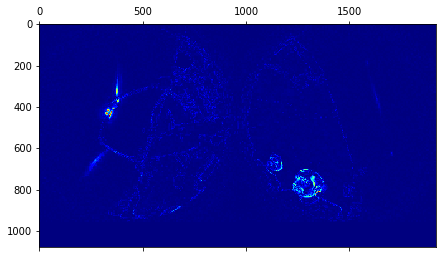

In [30]:
plt.matshow(data[50], cmap='jet')

In [149]:
idx=0
pix_imgs[idx,pixel_cos[idx][0]-20:pixel_cos[idx][0]+20,pixel_cos[idx][1]-20:pixel_cos[idx][1]+20]
np.max(data[idx])

127.0

In [54]:
x_off = (200, 800)
y_off = (200, 700)
pixel_cos = []
pix_imgs = data[::3]
kernel = np.ones((40, 40))
len(pix_imgs)
for idx, img in enumerate(pix_imgs):
    conv = ndimage.convolve(img[x_off[0]:x_off[1],y_off[0]:y_off[1]], kernel, mode='constant')
    pixel_cos.append(np.array(np.unravel_index(np.argmax(conv), conv.shape)) + [x_off[0], y_off[0]])
    print("Pixel Nr:", idx, ". Co:", pixel_cos[-1])

Pixel Nr: 0 . Co: [307 542]
Pixel Nr: 1 . Co: [311 517]
Pixel Nr: 2 . Co: [323 493]
Pixel Nr: 3 . Co: [331 475]
Pixel Nr: 4 . Co: [335 459]
Pixel Nr: 5 . Co: [343 436]
Pixel Nr: 6 . Co: [347 419]
Pixel Nr: 7 . Co: [353 409]
Pixel Nr: 8 . Co: [358 395]
Pixel Nr: 9 . Co: [354 294]
Pixel Nr: 10 . Co: [367 377]
Pixel Nr: 11 . Co: [386 355]
Pixel Nr: 12 . Co: [390 352]
Pixel Nr: 13 . Co: [391 350]
Pixel Nr: 14 . Co: [390 355]
Pixel Nr: 15 . Co: [394 353]
Pixel Nr: 16 . Co: [419 344]
Pixel Nr: 17 . Co: [437 335]
Pixel Nr: 18 . Co: [452 330]
Pixel Nr: 19 . Co: [467 323]
Pixel Nr: 20 . Co: [482 320]
Pixel Nr: 21 . Co: [498 315]
Pixel Nr: 22 . Co: [513 312]
Pixel Nr: 23 . Co: [530 308]
Pixel Nr: 24 . Co: [567 303]
Pixel Nr: 25 . Co: [567 302]
Pixel Nr: 26 . Co: [564 305]
Pixel Nr: 27 . Co: [566 307]
Pixel Nr: 28 . Co: [577 315]
Pixel Nr: 29 . Co: [591 325]
Pixel Nr: 30 . Co: [601 338]
Pixel Nr: 31 . Co: [611 355]
Pixel Nr: 32 . Co: [617 371]
Pixel Nr: 33 . Co: [626 387]
Pixel Nr: 34 . Co: [629 

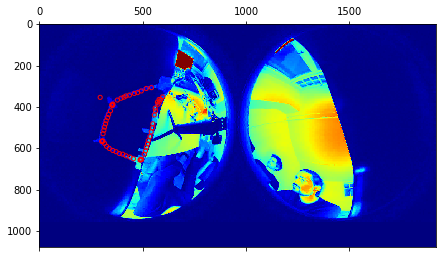

In [55]:
x_off = (200, 800)
y_off = (200, 700)
#plt.matshow(im0[x_off[0]:x_off[1],y_off[0]:y_off[1]], cmap='jet')
plt.matshow(im0, cmap='jet')

ax = plt.gca()
for co in pixel_cos:    
    ax.add_artist(plt.Circle(co[::-1], 10, color='r', fill=False))

In [44]:
def unit_vector(vector):
    """ Returns the unit vector of the vector.  """
    return vector / np.linalg.norm(vector)

def angle_between(v1, v2):
    """ Returns the angle in radians between vectors 'v1' and 'v2'::

            >>> angle_between((1, 0, 0), (0, 1, 0))
            1.5707963267948966
            >>> angle_between((1, 0, 0), (1, 0, 0))
            0.0
            >>> angle_between((1, 0, 0), (-1, 0, 0))
            3.141592653589793
    """
    v1_u = unit_vector(v1)
    v2_u = unit_vector(v2)
    return np.arccos(np.clip(np.dot(v1_u, v2_u), -1.0, 1.0))

In [63]:
polar_cos = []
radius = im0.shape[1]/4
mid_bottom = np.array([radius]*2)
mid_top = np.array([radius, im0.shape[1]/2 + radius])

print("radius:", radius, "mid_bottom:", mid_bottom, "mid_top :", mid_top)
for co in pixel_cos:
    if co[1] > im0.shape[1]/2:
        theta = (np.linalg.norm(co - mid_top) / radius) * np.pi / 2 # 0 - 90deg
        phi = angle_between(co - mid_top, np.array([0, 1])) # 0 - 360deg
    else:
        theta = np.pi - (np.linalg.norm(co - mid_bottom) / radius) * np.pi / 2 # 90 - 180deg
        phi = angle_between(co - mid_bottom, np.array([0, 1])) # 0 - 360deg
    polar_cos.append([theta, phi])
#print(polar_cos)

radius: 480.0 mid_bottom: [480. 480.] mid_top : [ 480. 1440.]


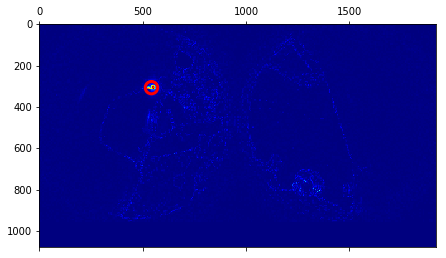

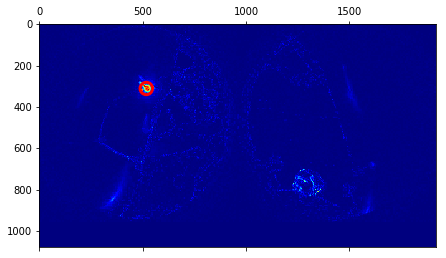

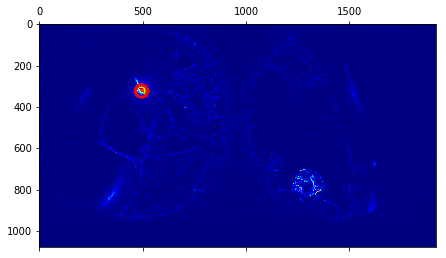

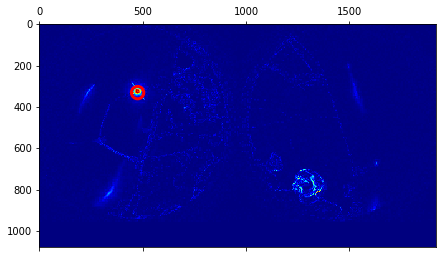

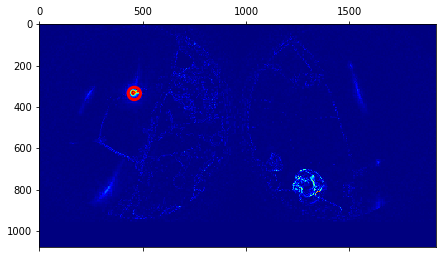

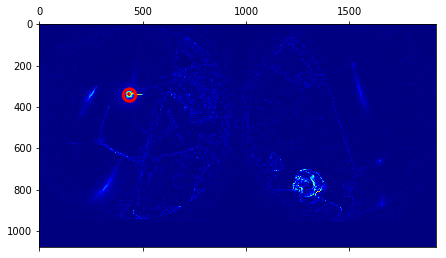

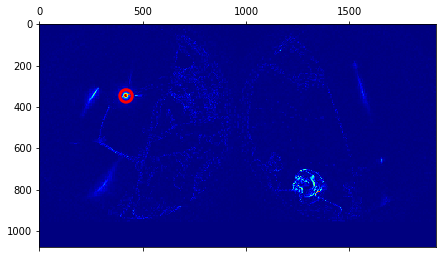

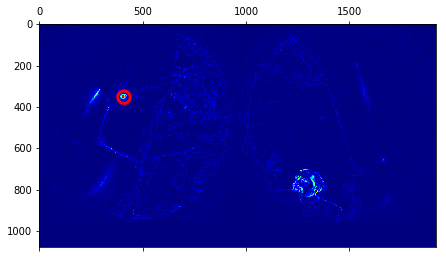

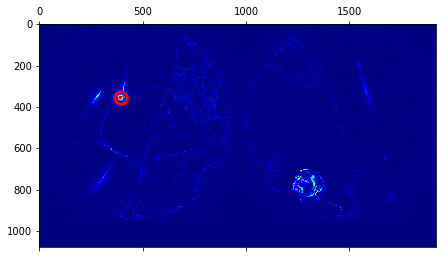

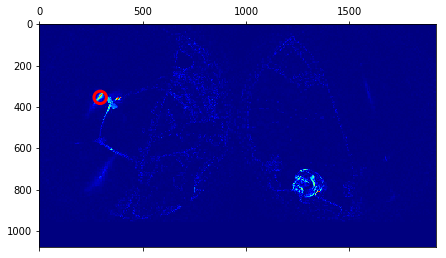

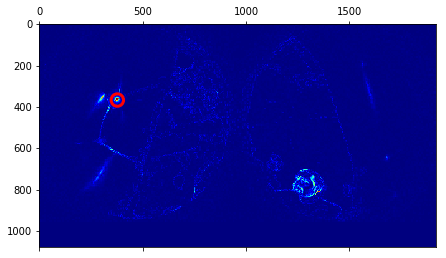

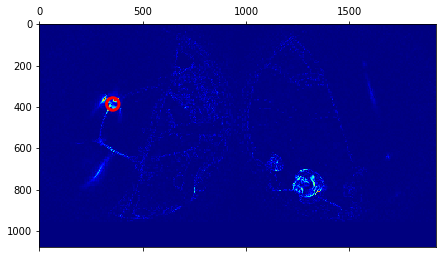

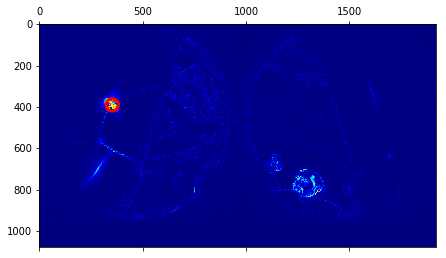

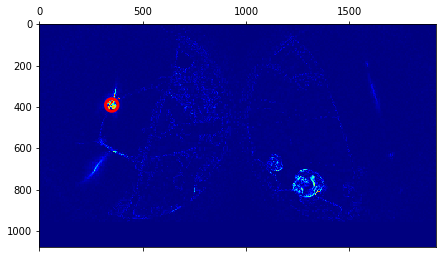

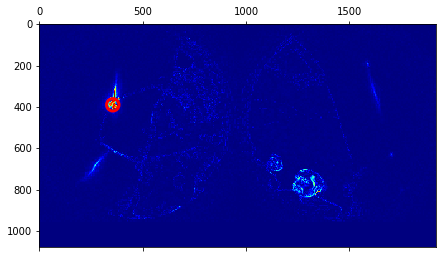

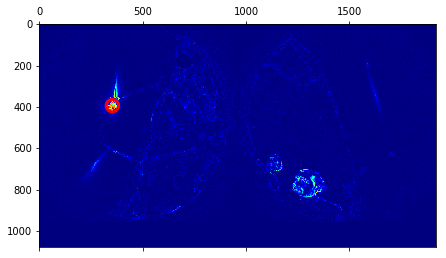

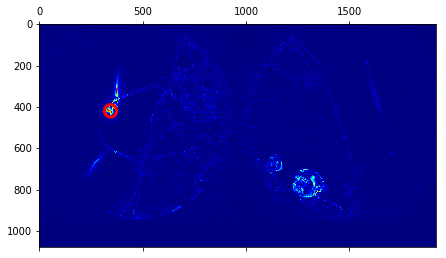

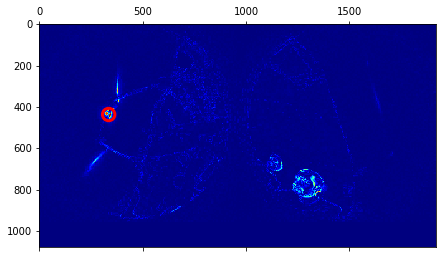

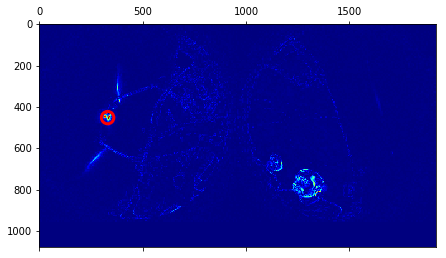

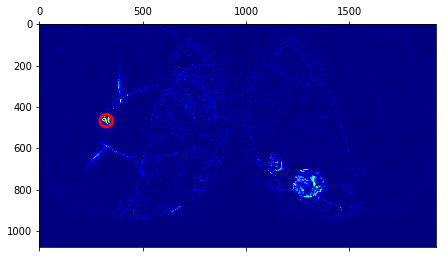

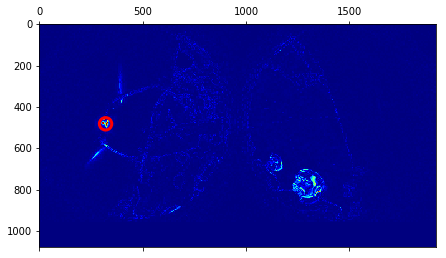

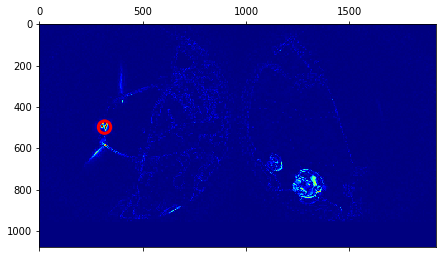

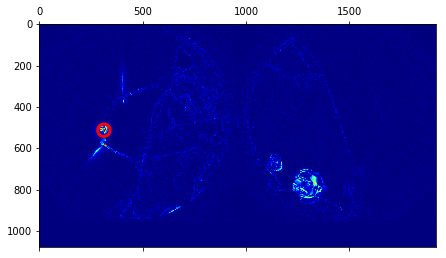

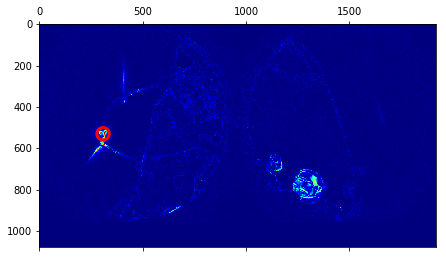

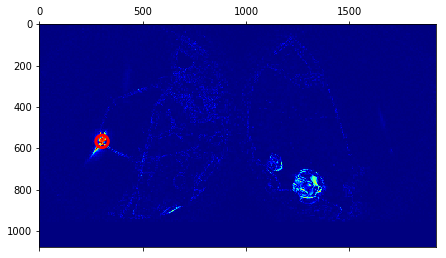

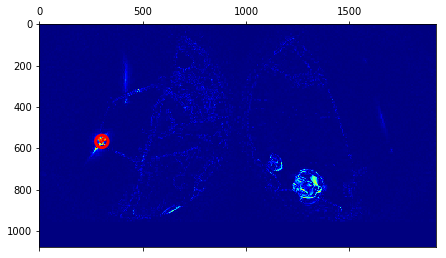

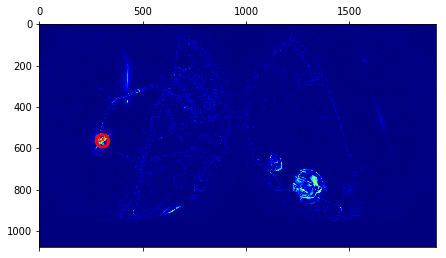

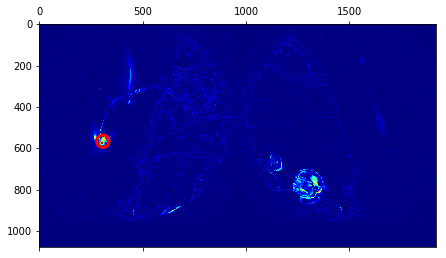

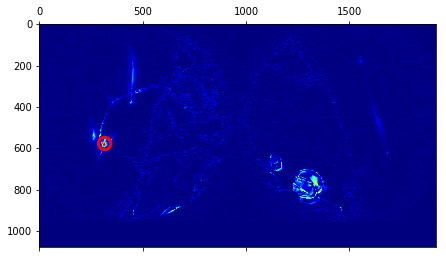

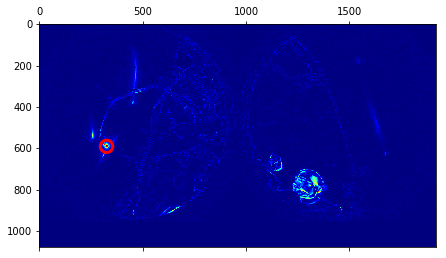

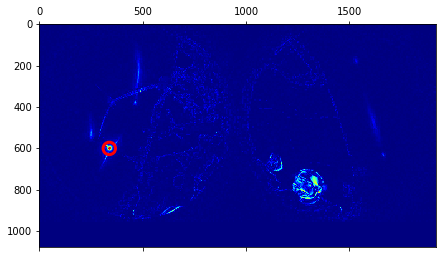

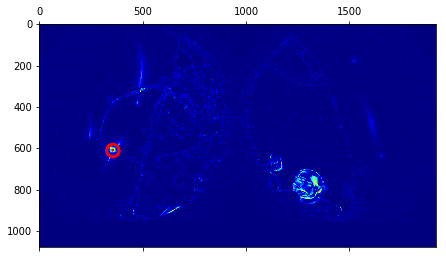

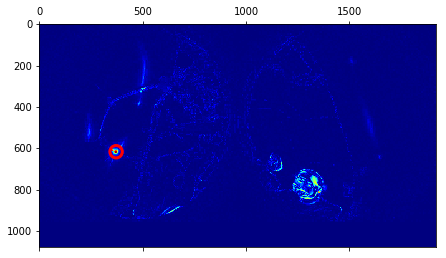

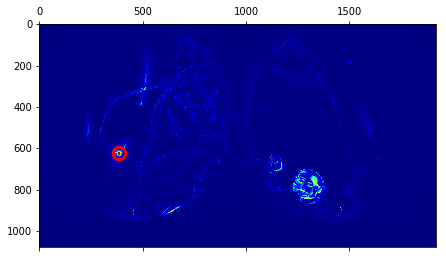

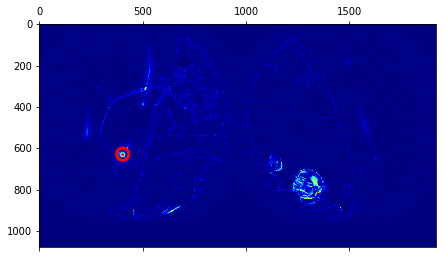

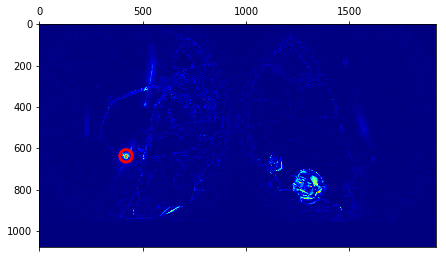

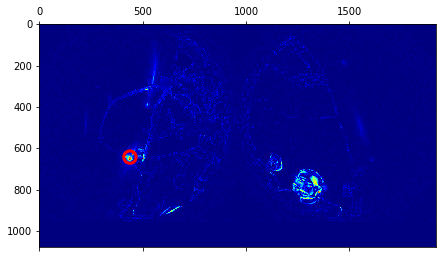

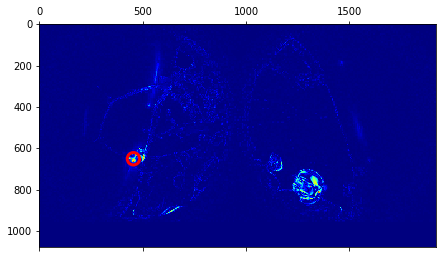

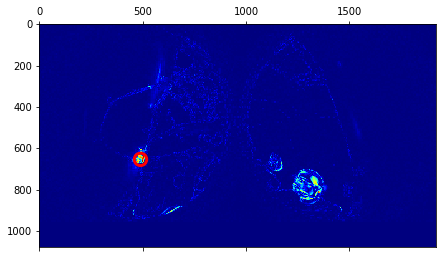

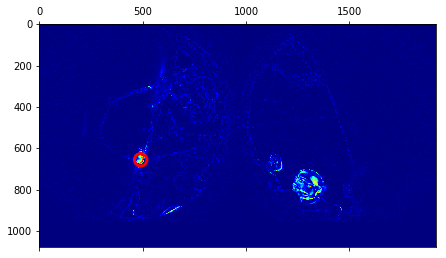

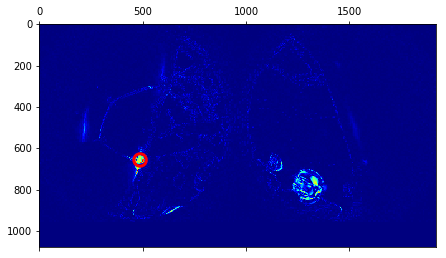

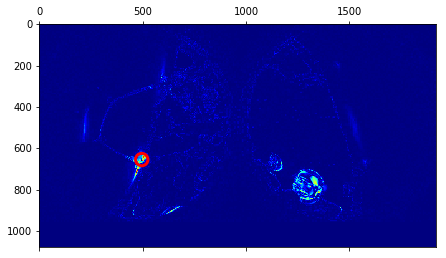

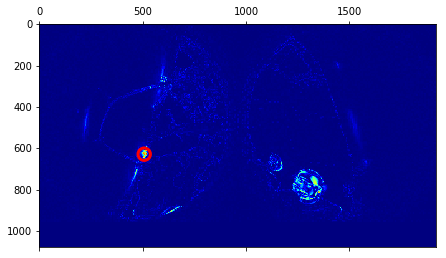

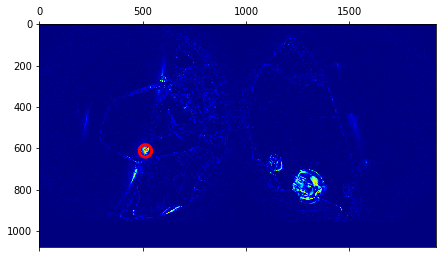

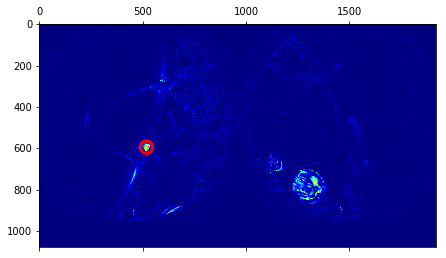

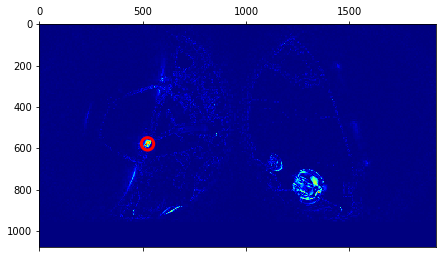

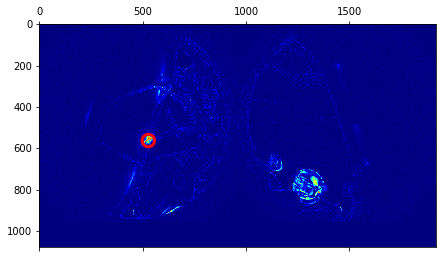

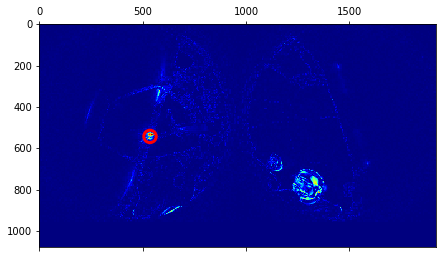

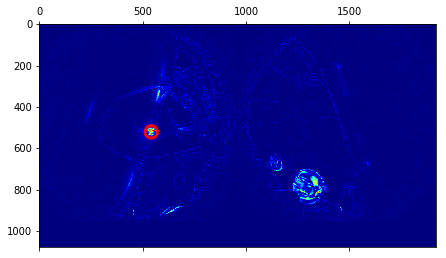

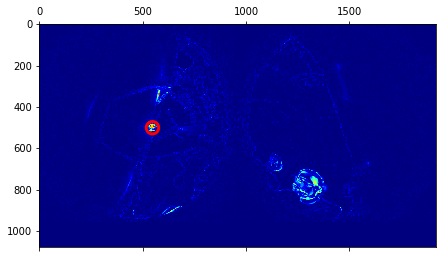

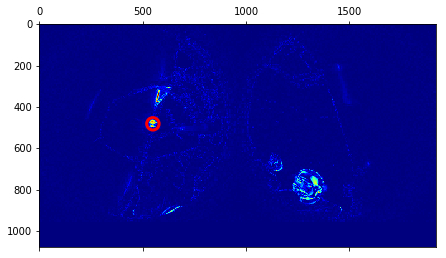

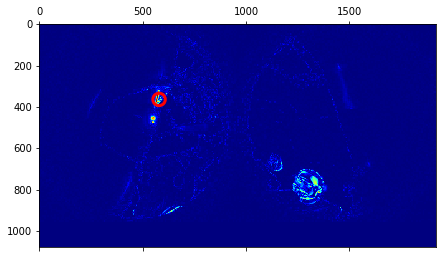

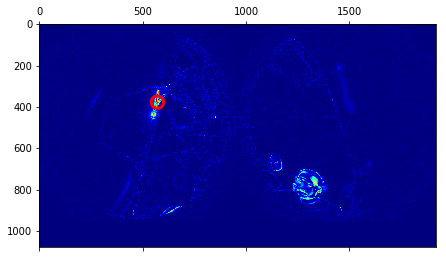

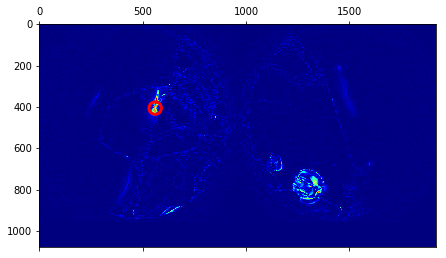

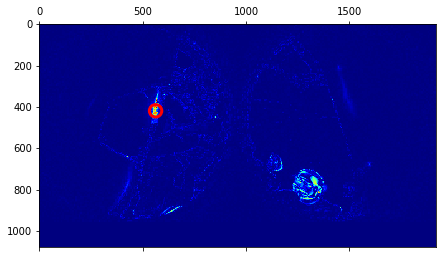

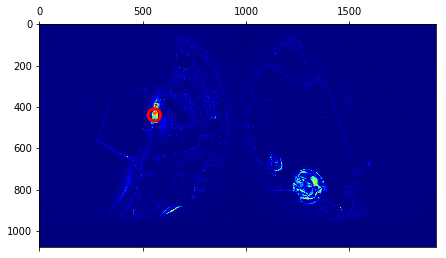

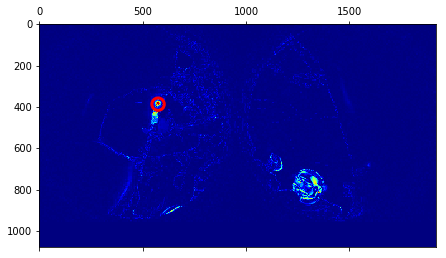

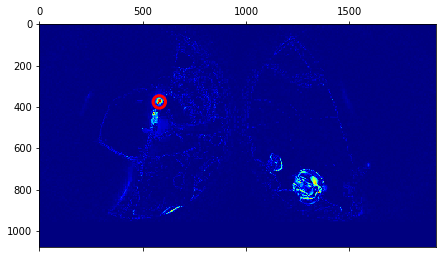

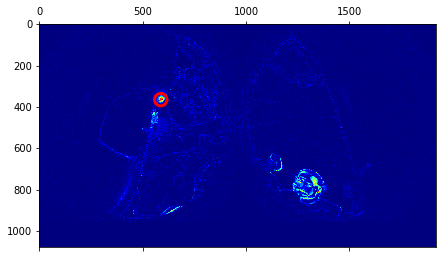

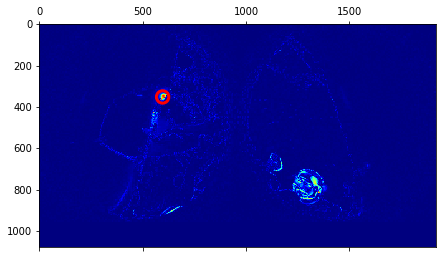

In [56]:
for idx, co in enumerate(pixel_cos):    
    plt.matshow(pix_imgs[idx], cmap='jet')
    ax = plt.gca()
    #ax.set_title("Pixel Nr:", str(idx))
    ax.add_artist(plt.Circle(co[::-1], 30, color='r', fill=False, linewidth=3))

KeyboardInterrupt: 

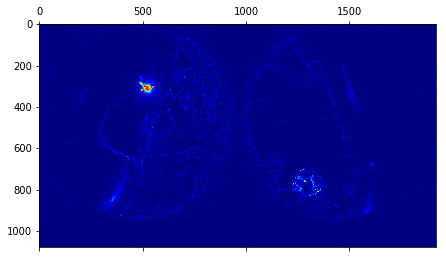

In [26]:
kernel = np.ones([100, 100])

im_idx = 2
max_pix = 0
max_co = [0,0]
for i in range(im0.shape[0] - kernel.shape[0]):
    for j in range(im0.shape[1] - kernel.shape[1]):    
        val = np.sum(data[im_idx, i:i+kernel.shape[0], j:j+kernel.shape[1]]*kernel)
        if val > max_pix:
            max_pix = val
            max_co = [int(i+kernel.shape[0]/2), int(j+kernel.shape[1]/2)]
print(max_pix, max_co)

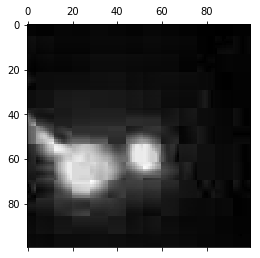

In [51]:
plt.matshow(data[2, 250:350, 500:600], cmap='gray')


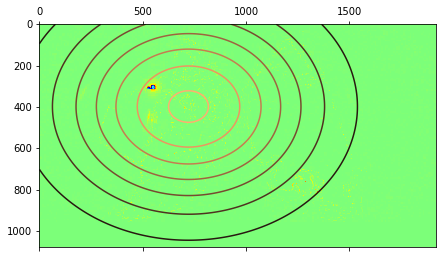

In [39]:
plt.matshow(data[0], cmap='jet')

params = fitgaussian(data[0])
fit = gaussian(*params)

plt.contour(fit(*np.indices(data.shape[1:])), cmap=plt.cm.copper)
ax = plt.gca()
(height, x, y, width_x, width_y) = params


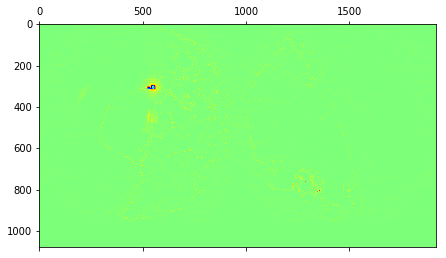

In [32]:
ref_img.shape
plt.matshow(data[0], cmap='jet')

In [35]:
import numpy as np
from numpy import pi, r_
import matplotlib.pyplot as plt
from scipy import optimize

def gaussian(height, center_x, center_y, width_x, width_y):
    """Returns a gaussian function with the given parameters"""
    width_x = float(width_x)
    width_y = float(width_y)
    return lambda x,y: height*np.exp(
                -(((center_x-x)/width_x)**2+((center_y-y)/width_y)**2)/2)

def moments(data):
    """Returns (height, x, y, width_x, width_y)
    the gaussian parameters of a 2D distribution by calculating its
    moments """
    total = data.sum()
    X, Y = np.indices(data.shape)
    x = (X*data).sum()/total
    y = (Y*data).sum()/total
    col = data[:, int(y)]
    width_x = np.sqrt(np.abs((np.arange(col.size)-y)**2*col).sum()/col.sum())
    row = data[int(x), :]
    width_y = np.sqrt(np.abs((np.arange(row.size)-x)**2*row).sum()/row.sum())
    height = data.max()
    return height, x, y, width_x, width_y

def fitgaussian(data):
    """Returns (height, x, y, width_x, width_y)
    the gaussian parameters of a 2D distribution found by a fit"""
    params = moments(data)
    errorfunction = lambda p: np.ravel(gaussian(*p)(*np.indices(data.shape)) -
                                 data)
    p, success = optimize.leastsq(errorfunction, params)
    return p

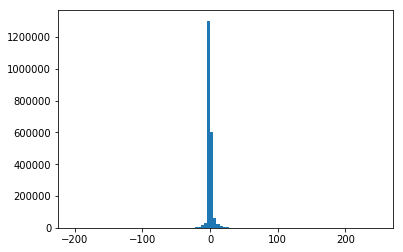

In [61]:
plt.hist((im[:,:,1] - im0).reshape(-1), bins=100);

In [106]:
pix_imgs = data[::3]
len(pix_imgs)

60